In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


#df = pd.read_csv(r'C:\Users\marya\PVision\Data\solar_weather.csv')
df = pd.read_csv('../Data/solar_weather.csv')
print(df.head())


                  Time  Energy delta[Wh]  GHI  temp  pressure  humidity  \
0  2017-01-01 00:00:00                 0  0.0   1.6      1021       100   
1  2017-01-01 00:15:00                 0  0.0   1.6      1021       100   
2  2017-01-01 00:30:00                 0  0.0   1.6      1021       100   
3  2017-01-01 00:45:00                 0  0.0   1.6      1021       100   
4  2017-01-01 01:00:00                 0  0.0   1.7      1020       100   

   wind_speed  rain_1h  snow_1h  clouds_all  isSun  sunlightTime  dayLength  \
0         4.9      0.0      0.0         100      0             0        450   
1         4.9      0.0      0.0         100      0             0        450   
2         4.9      0.0      0.0         100      0             0        450   
3         4.9      0.0      0.0         100      0             0        450   
4         5.2      0.0      0.0         100      0             0        450   

   SunlightTime/daylength  weather_type  hour  month  
0                  

In [26]:
df['Time']=pd.to_datetime(df['Time'])
df['Time'].diff().value_counts().head(10)

Time
0 days 00:15:00    196765
1 days 00:15:00         6
2 days 00:15:00         2
5 days 00:15:00         1
4 days 00:15:00         1
Name: count, dtype: int64

Find the shape

In [27]:
print(df.shape)

(196776, 17)


Find info

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Time                    196776 non-null  datetime64[ns]
 1   Energy delta[Wh]        196776 non-null  int64         
 2   GHI                     196776 non-null  float64       
 3   temp                    196776 non-null  float64       
 4   pressure                196776 non-null  int64         
 5   humidity                196776 non-null  int64         
 6   wind_speed              196776 non-null  float64       
 7   rain_1h                 196776 non-null  float64       
 8   snow_1h                 196776 non-null  float64       
 9   clouds_all              196776 non-null  int64         
 10  isSun                   196776 non-null  int64         
 11  sunlightTime            196776 non-null  int64         
 12  dayLength               196776

Find the null

In [29]:
print(df.isnull().sum())

Time                      0
Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64


Duplicate Rows

In [30]:
df.duplicated().sum()

0

convert the energy delta to power KW

In [31]:
df['Power[kW]'] = df['Energy delta[Wh]'] *4/1000
df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month,Power[kW]
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1,0.0
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1,0.0
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1,0.0
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1,0.0
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1,0.0


analyis the target

In [32]:
df['Power[kW]'].describe()

count    196776.000000
mean          2.292033
std           4.179296
min           0.000000
25%           0.000000
50%           0.000000
75%           2.308000
max          20.080000
Name: Power[kW], dtype: float64

### Correlation all feature with target

In [33]:
corr=df.select_dtypes(include='number').corr()
target_corr=corr['Power[kW]'].sort_values(ascending=False)
print(target_corr)

Power[kW]                 1.000000
Energy delta[Wh]          1.000000
GHI                       0.914619
isSun                     0.526952
sunlightTime              0.437296
SunlightTime/daylength    0.402523
temp                      0.378554
dayLength                 0.280695
pressure                  0.115219
wind_speed                0.029385
month                    -0.049307
snow_1h                  -0.050914
rain_1h                  -0.059881
hour                     -0.080877
weather_type             -0.170046
clouds_all               -0.190241
humidity                 -0.544407
Name: Power[kW], dtype: float64


correlation between numerical virables

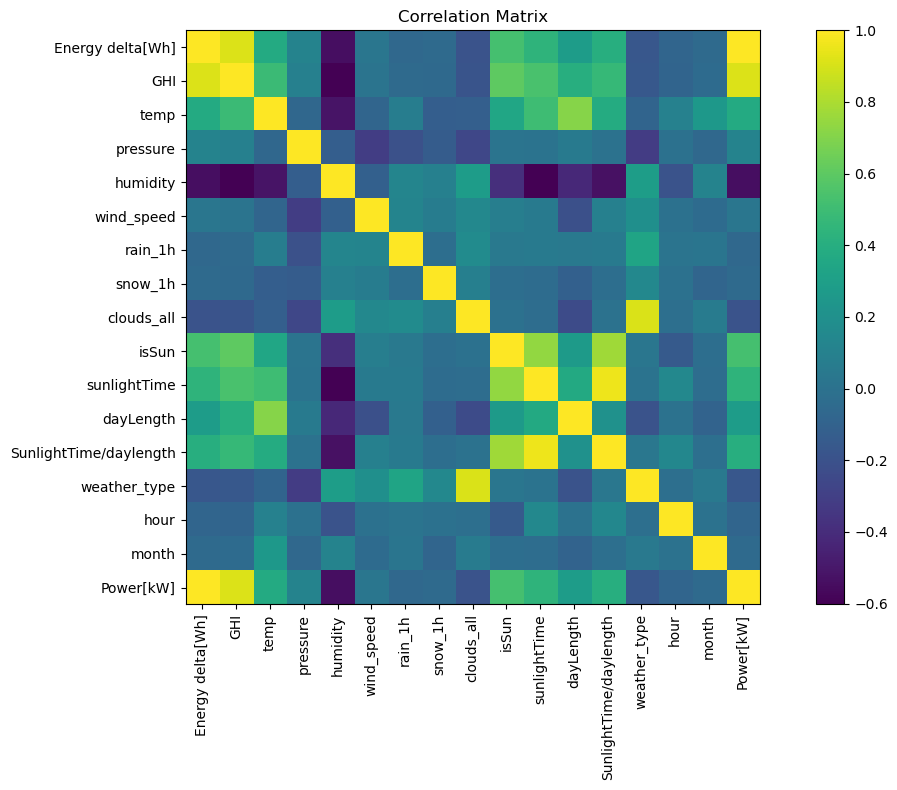

In [34]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

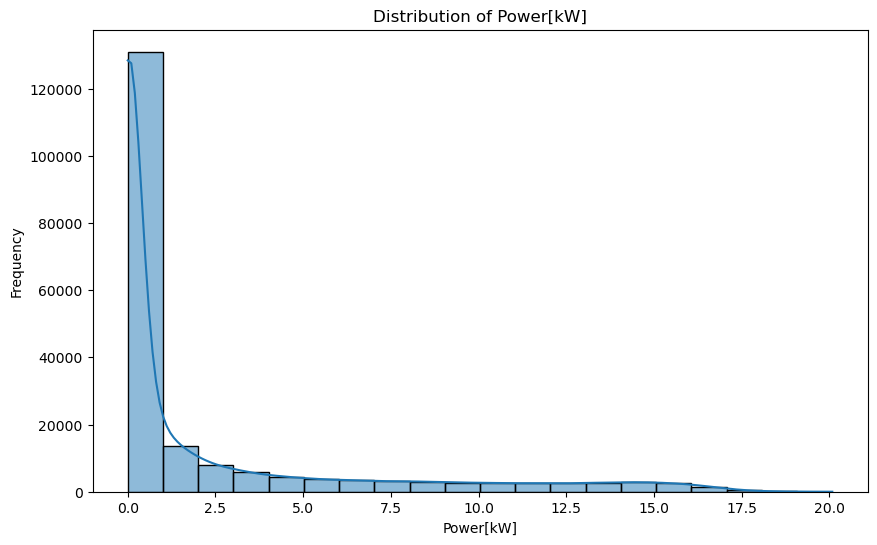

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Power[kW]'], bins=20, kde=True)
plt.title('Distribution of Power[kW]')
plt.xlabel('Power[kW]')
plt.ylabel('Frequency')
plt.show()


In [36]:
df.groupby('isSun')['Power[kW]'].agg(['count','mean','min','max'])

,count,mean,min,max
isSun,,,,
0,94460,0.00000,0.0,0.00
1,102316,4.40808,0.0,20.08


to see the production during the day (each hour)

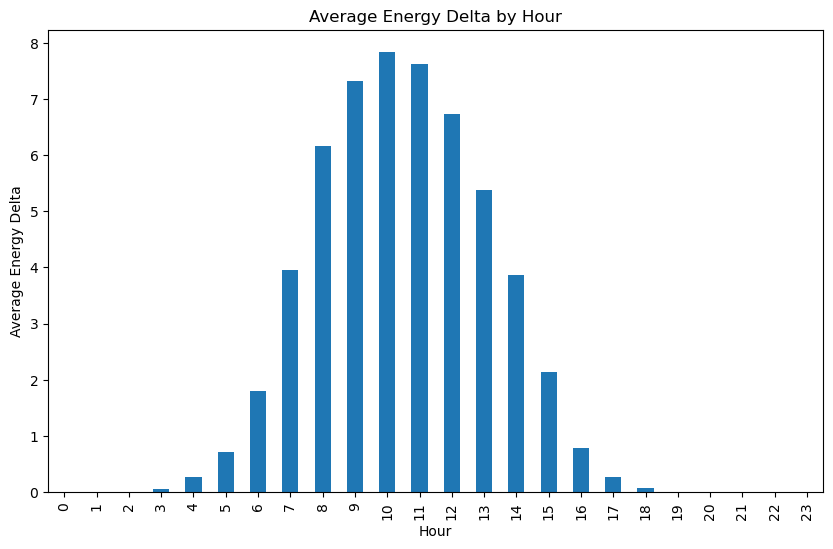

In [37]:
hourly_production = df.groupby('hour')['Power[kW]'].mean()
plt.figure(figsize=(10, 6))
hourly_production.plot(kind='bar')
plt.title('Average Energy Delta by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Energy Delta')
plt.show()

to see the production during the months , and see the differnce between winter and summer

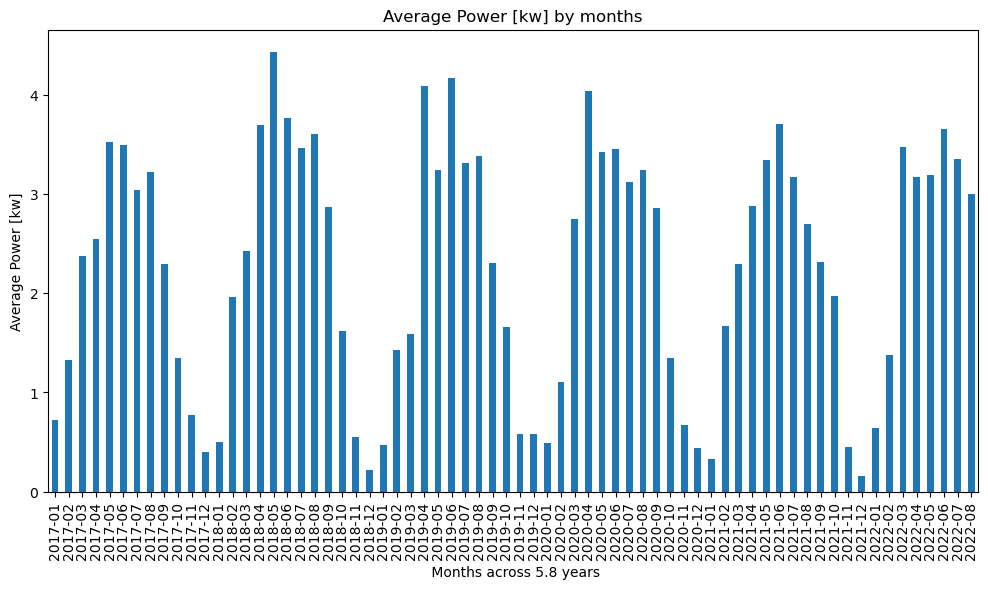

In [38]:
df['year_month']=df['Time'].dt.to_period('M')
df.head()
monthly_production = df.groupby('year_month')['Power[kW]'].mean()
plt.figure(figsize=(12, 6))
monthly_production.plot(kind='bar')
plt.title('Average Power [kw] by months')
plt.xlabel(' Months across 5.8 years')
plt.ylabel('Average Power [kw]')
plt.show()

the relation between GHI and energy delta

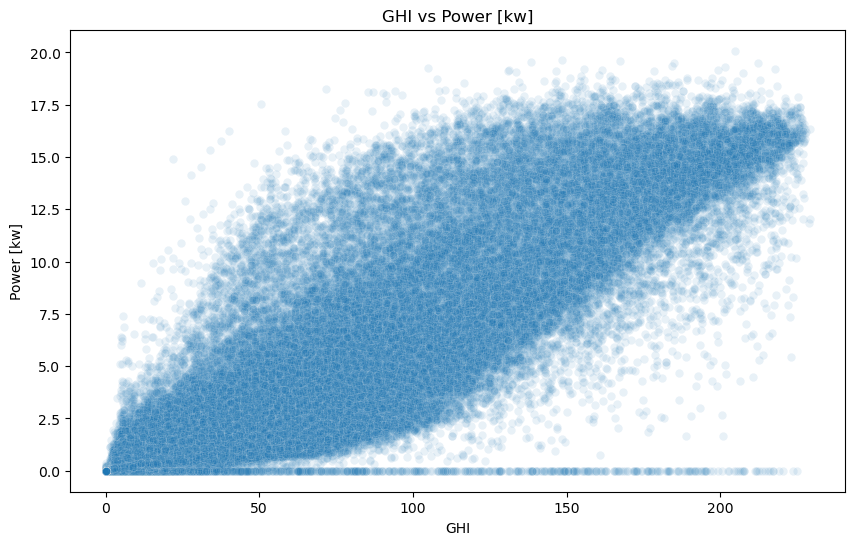

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GHI', y='Power[kW]', data=df , alpha=0.1)
plt.title('GHI vs Power [kw]')
plt.xlabel('GHI')
plt.ylabel('Power [kw]')
plt.show()

the effect of clouds on energy

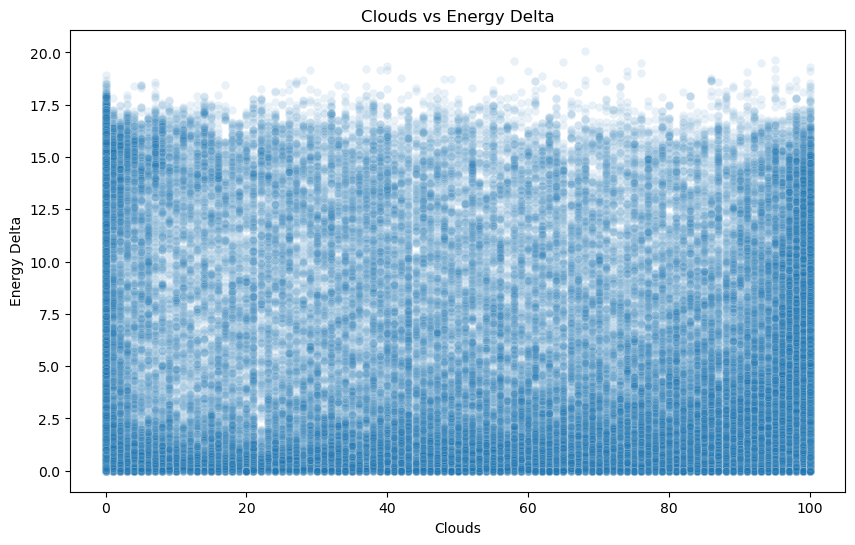

In [40]:
plt.figure(figsize=(10, 6))
day_df=df[df['isSun']==1]
sns.scatterplot(x='clouds_all', y='Power[kW]', data=day_df , alpha=0.1)
plt.title('Clouds vs Energy Delta')
plt.xlabel('Clouds')
plt.ylabel('Energy Delta')
plt.show()

find  outliers

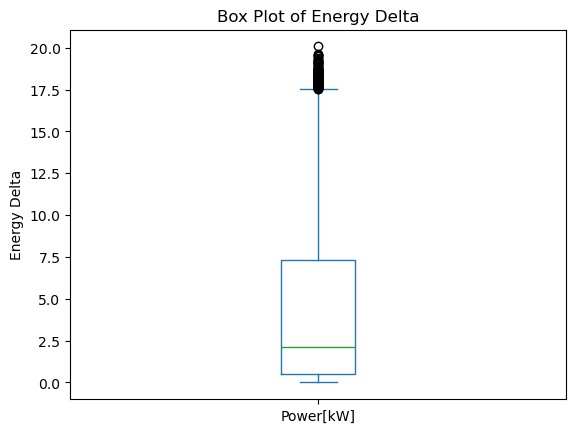

In [41]:
day_only=df[df['isSun']==1]
day_only['Power[kW]'].plot(kind='box')
plt.title('Box Plot of Energy Delta')
plt.ylabel('Energy Delta')
plt.show()

استخراج الحالات المشتبه بها او فيه عطل فالجهاز و نضع  isSun==1 and GHI(global horizontal irradiance)  ==0

In [42]:
suspicious=df[(df['isSun']==1)&(df['GHI']==0)]
print(len(suspicious))
print(suspicious[['Time','GHI','Power[kW]','clouds_all']].head(10))

584
                    Time  GHI  Power[kW]  clouds_all
347  2017-01-04 14:45:00  0.0        0.0         100
828  2017-01-14 15:00:00  0.0        0.0          73
924  2017-01-15 15:00:00  0.0        0.0          53
988  2017-01-16 07:00:00  0.0        0.0          36
1084 2017-01-17 07:00:00  0.0        0.0          87
1693 2017-01-23 15:15:00  0.0        0.0         100
2043 2017-01-27 06:45:00  0.0        0.0           0
2139 2017-01-28 06:45:00  0.0        0.0           0
2366 2017-01-30 15:30:00  0.0        0.0         100
2906 2017-02-05 06:30:00  0.0        0.0         100


هنا بعد ازاله وقت الشروق والغروب

In [43]:
very_suspicious = suspicious[(suspicious['hour'] >= 10) & (suspicious['hour'] <= 15)]
print('suspicious cases during the day: ', len(very_suspicious))
print(very_suspicious[['GHI','Power[kW]','clouds_all']].head(10))

suspicious cases during the day:  134
       GHI  Power[kW]  clouds_all
347    0.0      0.000         100
828    0.0      0.000          73
924    0.0      0.000          53
1693   0.0      0.000         100
2366   0.0      0.000         100
3135   0.0      0.000         100
27519  0.0      0.008          14
28190  0.0      0.000         100
28861  0.0      0.000          34
29628  0.0      0.000         100


وهنا بعد ازاله الغيوم التي تؤثر على التقاط الجهاز  Outliers

In [44]:
truly_suspicious = very_suspicious[very_suspicious['clouds_all'] < 50]
print('truly sus: ', len(truly_suspicious))

truly sus:  23
